### Lab01 Introduction to PyTorch, Tensors
#### csci e-104 Advanced Deep Learning

## What is PyTorch
PyTorch is a scalable and multiplatform programming interface for implementing and running machine learning algorithms, including convenience wrappers for deep learning. PyTorch was primarily developed by the researchers and engineers from the Facebook AI Research (FAIR) lab. Its development also involves many contributions from the community. PyTorch was initially released in September 2016 and is free and open source under the modified BSD license. Many machine learning researchers and practitioners from academia and industry have adapted PyTorch to develop deep learning solutions, such as Tesla Autopilot, Uber’s Pyro, and Hugging Face’s Transformers (https://pytorch.org/ecosystem/).

To improve the performance of training machine learning models, PyTorch allows execution on CPUs, GPUs, and XLA devices such as TPUs. However, its greatest performance capabilities can be discovered when using GPUs and XLA devices. PyTorch supports CUDA-enabled and ROCm GPUs officially. PyTorch’s development is based on the Torch library (www.torch.ch). As its name implies, the Python interface is the primary development focus of PyTorch.

PyTorch is built around a computation graph composed of a set of nodes. Each node represents an operation that may have zero or more inputs or outputs. PyTorch provides an imperative programming environment that evaluates operations, executes computation, and returns concrete values immediately. Hence, the computation graph in PyTorch is defined implicitly, rather than constructed in advance and executed after.

## Instaling PyTorch
Check your installed Python version. Simply, open Python prompt and read the version. I have 3.9.7. If you would like to work with another version, install that version. Nothing special about the version I have.

Create a conda virutal environment with the same version of Python, if possible.

`$ conda create env -n pyenv python=3.11.5`

Please go to: https://pytorch.org/get-started/locally/

Select your operating system, whether you want to install Pytorch with conda or some other way. The widget on that page will recommend the command you should run. For example, I have GPU card and want Cuda enabled. My screen looked like the following:

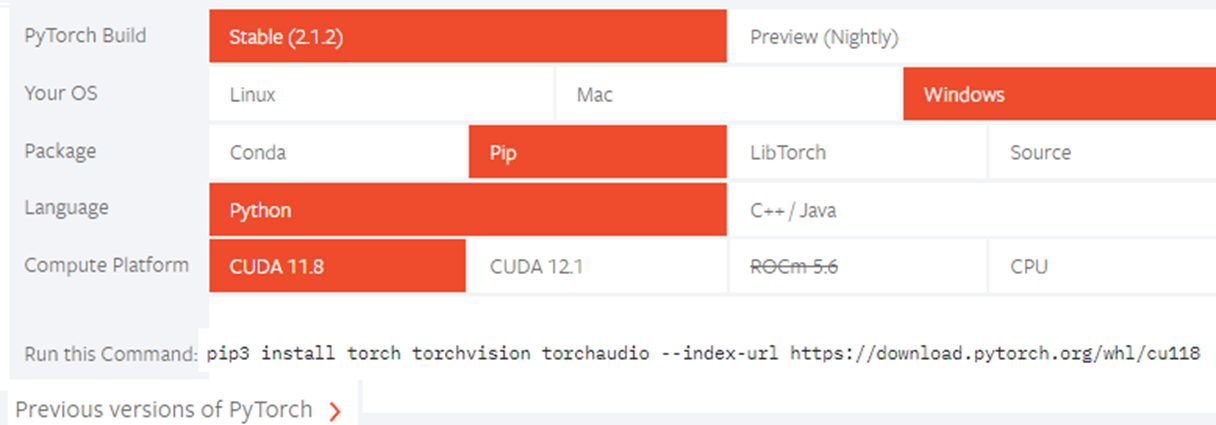

The command suggested to me reads:

That command will install PyTorch 2.1.2. 
On page https://pytorch.org/get-started/previous-versions/ I selected installation instruction for earlier version of PyTorch and cuda.
Your NVIDA card might require a newer version of CUDA. If yo operate an AMD card, you must use AMD libraries. On Google Colab, you have all software installed.

The test for the availability of the GPU card gave a positive result.

In [1]:
import torch
import numpy as np
print(torch.cuda.is_available())

True




## PyTorch Tensors

A tensor is both a container for numbers as well as a set of rules that define transformations
between tensors that produce new tensors. It’s probably easiest for us to
think about tensors as multidimensional arrays. Every tensor has a rank that corresponds
to its dimensional space. A simple scalar (e.g., 1) can be represented as a tensor
of rank 0, a vector is rank 1, an n × n matrix is rank 2, and so on. We created a rank 2 tensor with random values by using `torch.rand()`. 

### Tensor creation 
By special functions

In [2]:
print(torch.rand(2,2))

tensor([[0.4002, 0.4114],
        [0.8693, 0.3491]])


### From Lists
We can also create tensors from lists.

In [3]:
x = torch.tensor([[0,0,1],[1,1,1],[0,0,0]])
x

tensor([[0, 0, 1],
        [1, 1, 1],
        [0, 0, 0]])

### Special Tensors
You can use special creation functions to generate particular types of tensors. In particular, ones() and zeroes() will generate tensors filled with 1s and 0s, respectively:

In [4]:
torch.zeros(2,2)

tensor([[0., 0.],
        [0., 0.]])

In [5]:
torch.ones(3,2)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])

### From a Numpy Array
Tensors can be created from NumPy arrays (and vice versa - see Bridge with NumPy).

In [6]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

#### Tensor to NumPy array

In [7]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


### From another tensor:

The new tensor retains the properties (shape, datatype) of the argument tensor, unless explicitly overridden.

In [8]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.9514, 0.1242],
        [0.9140, 0.0833]]) 



### Attributes of tensors
Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [9]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Modifying tensors
We can change an element in a tensor by using standard Python indexing:

In [10]:
x[0][0] = 5

In [11]:
x

tensor([[5, 0, 1],
        [1, 1, 1],
        [0, 0, 0]])

#### Standard numpy-like indexing and slicing:

In [12]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


### Operations on Tensors

There are over 300 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more. (https://pytorch.org/docs/stable/torch.html)

Operations range from finding the maximum element to
applying a Fourier transform. 

Each of these operations can be run on the GPU (at typically higher speeds than on a CPU). If you’re using Colab, allocate a GPU by going to Runtime > Change runtime type > GPU.

By default, tensors are created on the CPU. We need to explicitly move tensors to the GPU using `.to()` method (after checking for GPU availability). Keep in mind that copying large tensors across devices can be expensive in terms of time and memory!

You can perform standard mathematical operations with tensors (e.g., adding two
tensors together):

In [13]:
a = torch.ones(1,2) + torch.ones(1,2)
print(a)

tensor([[2., 2.]])


In [14]:
torch.rand(1).item()

0.7992256283760071

#### Location of tensors
When a tensor is created we could ask for its location, CPU or GPU, bu reading property `tensor.device`

In [15]:
cpu_tensor = torch.rand(2)
cpu_tensor.device


device(type='cpu')

In [16]:
cpu_tensor

tensor([0.4238, 0.0775])

Command: `torch.cuda.is_available()` will tell us whether PyTorch sees our GPU card.

In [17]:
torch.cuda.is_available()

True

If GPU device is present, we could move `cpu_tensor` to GPU, by invoking `tensor.to("cuda")`

In [18]:
gpu_tensor = cpu_tensor.to("cuda")
gpu_tensor.device

device(type='cuda', index=0)

#### Functions `max()` and `argmax()`
We often need to find the maximum item in a tensor as well as the index that
contains the maximum value (as this often corresponds to the class that the neural
network has decided upon in its final prediction). These can be done with the `max()`
and `argmax()` functions. We can also use `item()` to extract a standard Python value
from a 1D tensor.

In [19]:
a =torch.rand(2,2).max()
print(a)

tensor(0.5121)


In [20]:
a.max().item()

0.5121157765388489

In [21]:
a =torch.rand(2,2)
print(a)
print(a.max())

tensor([[0.4542, 0.2555],
        [0.6909, 0.7231]])
tensor(0.7231)


Location of the maximum is deterined by:

In [22]:
a.argmax()

tensor(3)

Notice that the loction of the maximum is presented as the index of the position in the vector, representing unwrapped tensor.

### Spliting a Tensor
Often we want to split a single tensor into two or more tensors. For this, PyTorch provides a convenient `torch.chunk()` function, which divides an input tensor into a list of equally sized tensors. We can determine the desired number of splits as an integer using the chunks argument to split a tensor along the desired dimension specified by the `dim` argument. In this case, the total size of the input tensor along the specified dimension must be divisible by the desired number of splits. Alternatively, we can provide the desired sizes in a list using the `torch.split()` function

####  Providing the number of splits:

In [23]:
torch.manual_seed(1)
t = torch.rand(6)
print(t)

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


In [24]:
t_splits = torch.chunk(t, 3)
[item.numpy() for item in t_splits]

[array([0.7576316 , 0.27931088], dtype=float32),
 array([0.40306926, 0.73468447], dtype=float32),
 array([0.02928156, 0.7998586 ], dtype=float32)]

In this example, a tensor of size 6 was divided into a list of three tensors each with size 2. If the tensor size is not divisible by the chunks value, the last chunk will be smaller.

#### Providing the sizes of different splits.
nstead of defining the number of splits, we can also specify the sizes of the output tensors directly. Here, we are splitting a tensor of size 5 into tensors of sizes 3 and 2


In [25]:
torch.manual_seed(1)
t = torch.rand(5)
print(t)

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


In [26]:
t_splits = torch.split(t, split_size_or_sections=[3, 2])
[item.numpy() for item in t_splits]

[array([0.7576316 , 0.27931088, 0.40306926], dtype=float32),
 array([0.73468447, 0.02928156], dtype=float32)]

### Joining tensors 
Sometimes, we are working with multiple tensors and need to concatenate or stack them to create a single tensor. In this case, PyTorch functions such as `torch.stack()` and `torch.cat()` come in handy. For example, let’s create a 1D tensor, A, containing 1s with size 3, and a 1D tensor, B, containing 0s with size 2, and concatenate them into a 1D tensor, C, of size 5:

In [27]:
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


If we create 1D tensors A and B, both with size 3, then we can stack them together to form a 2D tensor

In [28]:
A = torch.ones(3)
B = torch.zeros(3)
S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


You can use `torch.cat()` to concatenate a sequence of tensors along a given dimension.

In [29]:
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


In [30]:
t1 = torch.cat([S, S, S], dim=1)
print(t1)

tensor([[1., 0., 1., 0., 1., 0.],
        [1., 0., 1., 0., 1., 0.],
        [1., 0., 1., 0., 1., 0.]])


In [31]:
t1 = torch.cat([S, S, S], dim=0)
print(t1)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]])


### Changing the type of tensor elements
Sometimes, we would like to change the type of a tensor; for example, from a LongTensor
to a FloatTensor. We can do this with to():

In [32]:
long_tensor = torch.tensor([[0,0,1],[1,1,1],[0,0,0]])
long_tensor.type()

'torch.LongTensor'

In [33]:
float_tensor = torch.tensor([[0,0,1],[1,1,1],[0,0,0]]).to(dtype=torch.float32)

In [34]:
float_tensor.type()

'torch.FloatTensor'

In [35]:
float_tensor

tensor([[0., 0., 1.],
        [1., 1., 1.],
        [0., 0., 0.]])

### In-place functions
Most functions that operate on a tensor and return a tensor create a new tensor to
store the result. However, if you want to save memory, look to see if an in-place function
is defined, which should be the same name as the original function but with an
appended underscore (_).

In [36]:
random_tensor = torch.rand(2,2)
random_tensor.log2()

tensor([[-0.3222, -1.3323],
        [-0.4067, -0.8122]])

In [37]:
random_tensor.log2_()

tensor([[-0.3222, -1.3323],
        [-0.4067, -0.8122]])

In [38]:
torch.Size([1,28,28])

torch.Size([1, 28, 28])

### Reshaping tensors
Another common operation is reshaping a tensor. This can often occur because your
neural network layer may require a slightly different input shape than what you currently
have to feed into it. For example, the Modified National Institute of Standards
and Technology (MNIST) dataset of handwritten digits is a collection of 28 × 28
images, but the way it’s packaged is in arrays of length 784. In some of the neural networks we need to turn those vectors back into 1 × 28 × 28 tensors (the leading 1 is
the number of channels—normally red, green, and blue—but as MNIST digits are
just grayscale, we have only one channel, 1). We can do this with either `view()` or
`reshape()`:

In [39]:
flat_tensor = torch.rand(784)
viewed_tensor = flat_tensor.view(1,28,28)
viewed_tensor.shape

torch.Size([1, 28, 28])

In [40]:
reshaped_tensor = flat_tensor.reshape(1,28,28)
reshaped_tensor.shape

torch.Size([1, 28, 28])

Note that the reshaped tensor’s shape has to have the same number of total elements
as the original. If you try `flat_tensor.reshape(3,28,28)`, you’ll see an error like
this:

In [41]:
flat_tensor.reshape(3,28,28)

RuntimeError: shape '[3, 28, 28]' is invalid for input of size 784

Now you might wonder what the difference is between `view()` and `reshape()`. The
answer is that `view()` operates as a view on the original tensor, so if the underlying
data is changed, the view will change too (and vice versa). However, `view()` can
throw errors if the required view is not contiguous; that is, it doesn’t share the same
block of memory it would occupy if a new tensor of the required shape was created
from scratch. If this happens, you have to call `tensor.contiguous()` before you can
use `view()`. However, `reshape()` does all that behind the scenes, so in general, it is recommended to use `reshape()` rather than `view()`.

Finally, you might need to rearrange the dimensions of a tensor. You will likely come
across this with images, which often are stored as `[height, width, channel]` tensors,
but PyTorch prefers to deal with these in a `[channel, height, width]`. You can
user `permute()` to deal with these in a fairly straightforward manner:

In [42]:
hwc_tensor = torch.rand(640,480,3)
chw_tensor = hwc_tensor.permute(2,0,1)
chw_tensor.shape

torch.Size([3, 640, 480])

Here, we’ve just applied permute to a `[640,480,3]` tensor, with the arguments being
the indexes of the tensor’s dimensions, so we want the final dimension (2, due to zero
indexing) to be at the front of our tensor, followed by the remaining two dimensions
in their original order.

### Tensor Broadcasting
Borrowed from NumPy, broadcasting allows you to perform operations between a
tensor and a smaller tensor. You can broadcast across two tensors if, starting backward
from their trailing dimensions:
• The two dimensions are equal.
• One of the dimensions is 1.
In our use of broadcasting, it works because 1 has a dimension of 1, and as there are
no other dimensions, the 1 can be expanded to cover the other tensor. If we tried to
add a [2,2] tensor to a [3,3] tensor, we’d get this error message:

But we could add a [1,3] tensor to the [3,3] tensor without any trouble. Broadcasting
is a handy little feature that increases brevity of code, and is often faster than
manually expanding the tensor yourself